## Step 1: Dataset and Dataset Preprocessing

In [ ]:
#Installing all required libraries and setting the path
!pip install cv


In [2]:
!pip3 install opencv-python

In [3]:
!pip3 install tensorflow --user

In [6]:
pip install numpy --upgrade --user

Note: you may need to restart the kernel to use updated packages.


In [1]:
# data config libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

# display config libraries
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# openCV
import cv2

# tensorflow and keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg19 import VGG19

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

C:\Users\Pranav\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.25.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Importing custom packages and utility files

from DataUtility import dataUtils
skinDataUtils = dataUtils()

from DataUtility import SKIN_CANCER_TUMOR_TYPE

from ModelTrainer import ModelTrainer
ModelTrainer = ModelTrainer()

from ModelValidator import ValidateModel
ValidateSkinCancerClassfier = ValidateModel()

## Benign Images

<br>

***Samples of the benign (cancerous) tumors...***

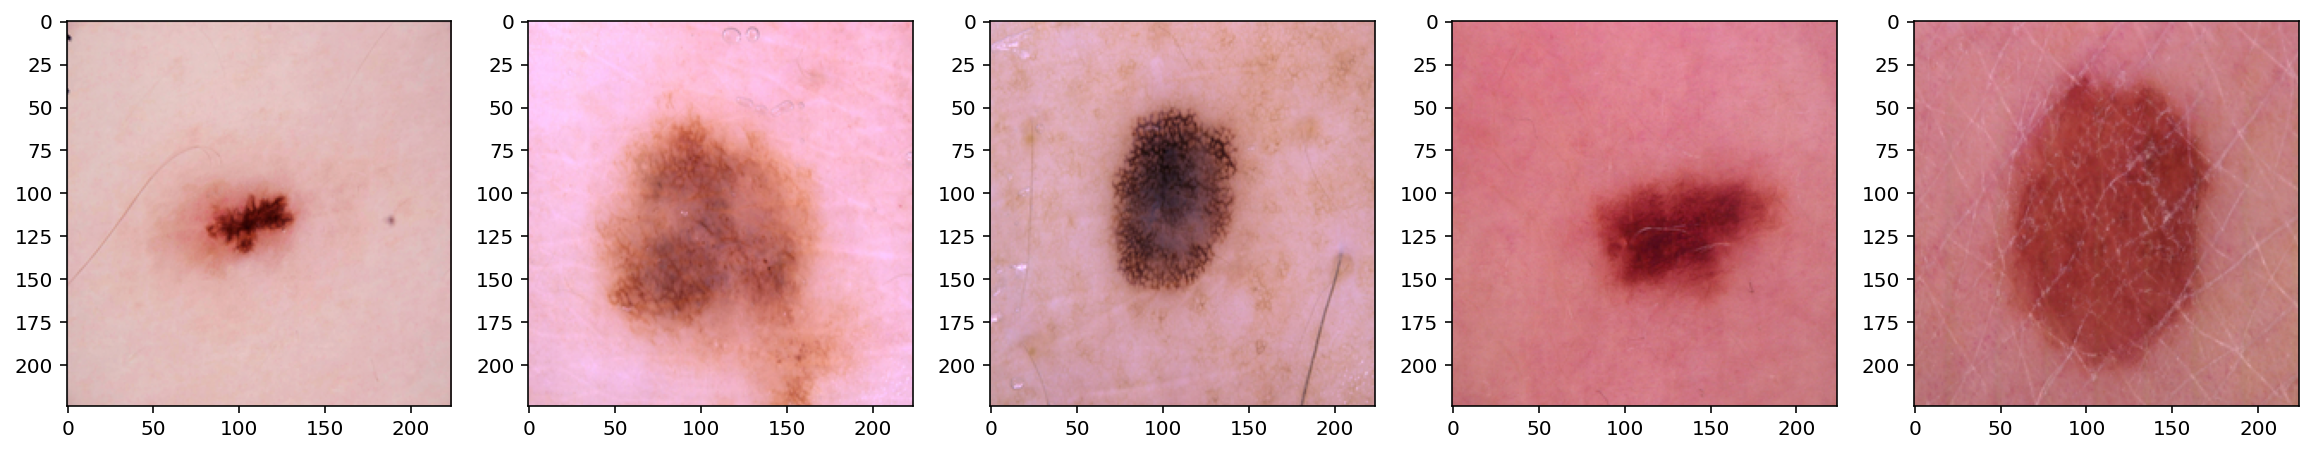

In [3]:
#Let us check if the dataset is loaded
skinDataUtils.PrintMarkdownText('***Samples of the benign (cancerous) tumors...***')
skinDataUtils.ReadAndDisplayInputImages(SKIN_CANCER_TUMOR_TYPE.BENIGN.value, 5)

## Malignant Images

<br>

***Samples of the malignant (non-cancerous) tumors...***

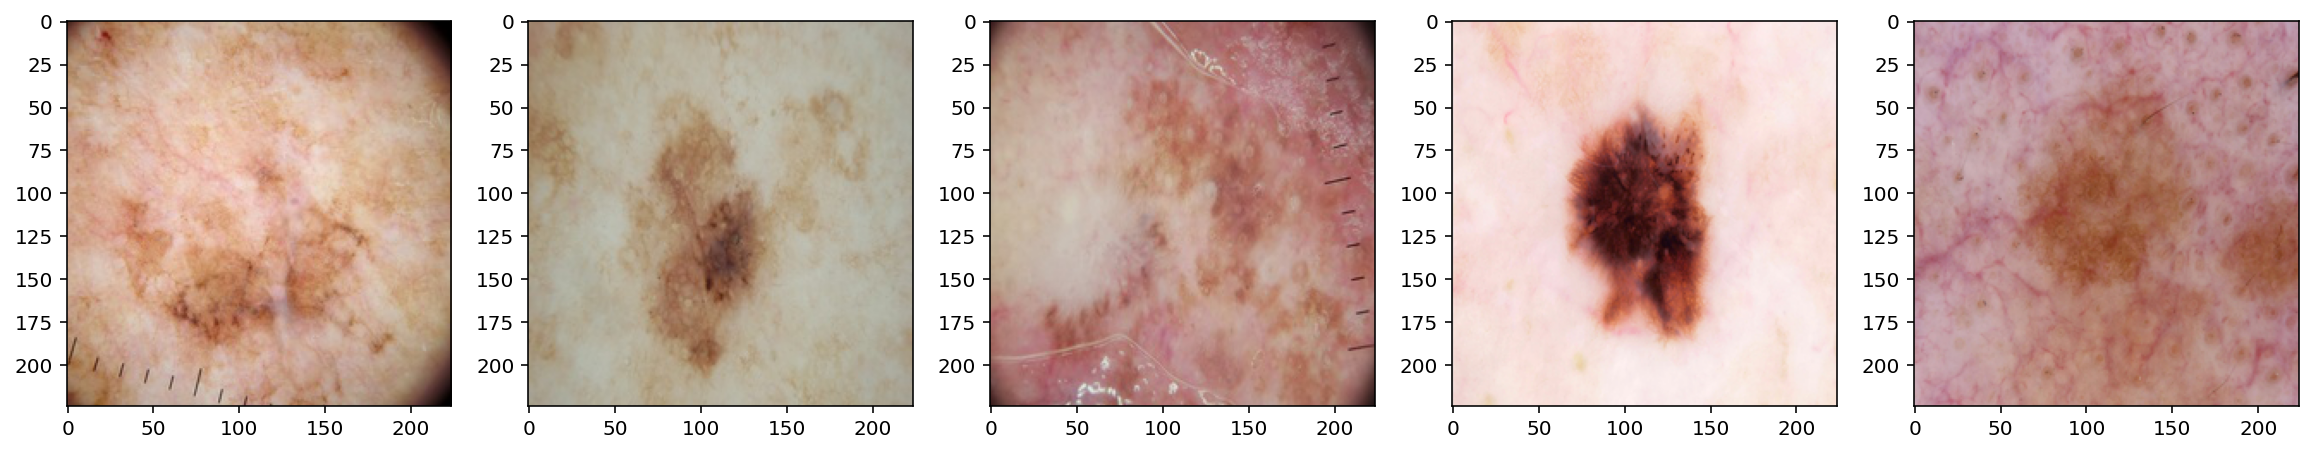

In [4]:
skinDataUtils.PrintMarkdownText('***Samples of the malignant (non-cancerous) tumors...***')
skinDataUtils.ReadAndDisplayInputImages(SKIN_CANCER_TUMOR_TYPE.MALIGNANT.value, 5)

## Data Labeling
Data Labeling is important while training since the model needs to project what image is labeled as which

We label them as Benign and Malignant. Benign refers to the type of cancer that does not spread, while malignant skin lesions can spread deeper within the tissues. 

In our case, melanoma and nevus are malginant by nature. It is essential to separate out the malignant cancer, since melanoma can be fatal if allowed to grow

In [5]:
skinCancer_df = skinDataUtils.GetLabelledSkinCancerData()

skinDataUtils.PrintMarkdownText('***Labelled skin cancer images...***')
skinCancer_df.head()

<br>

***Labelled skin cancer images...***

,filename,label
0,C:\Users\Pranav\Desktop\Treatment Visualizatio...,Malignant
1,C:\Users\Pranav\Desktop\Treatment Visualizatio...,Malignant
2,C:\Users\Pranav\Desktop\Treatment Visualizatio...,Benign
3,C:\Users\Pranav\Desktop\Treatment Visualizatio...,Benign
4,C:\Users\Pranav\Desktop\Treatment Visualizatio...,Malignant


In [6]:
#If we want information of annotated skin cancer data
skinDataUtils.PrintMarkdownText('***Skin Cancer Annotated data Info...***')
skinCancer_df.info()

<br>

***Skin Cancer Annotated data Info...***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3297 entries, 0 to 3296
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  3297 non-null   object
 1   label     3297 non-null   object
dtypes: object(2)
memory usage: 51.6+ KB


<br>

***Skin Cancer Annotated Benign and Malignant Images...***

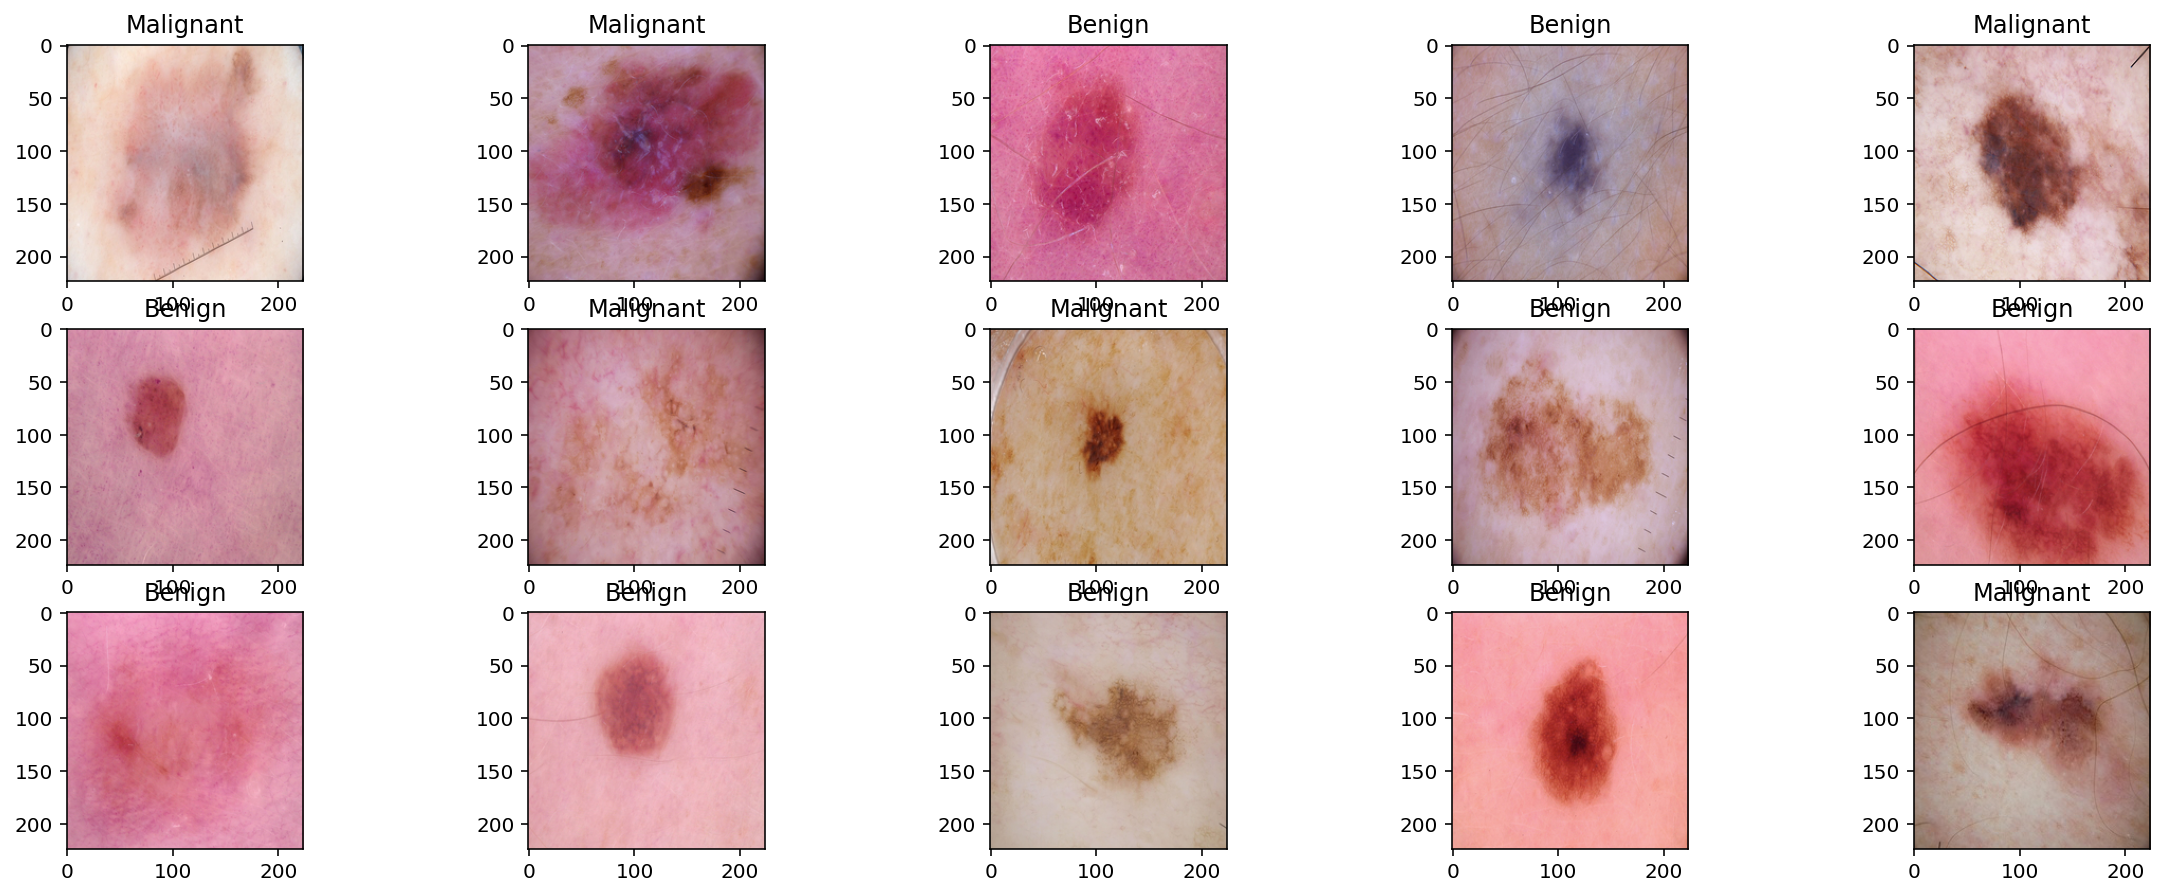

In [7]:
#The sample annotated images of both samples
skinDataUtils.PrintMarkdownText('***Skin Cancer Annotated Benign and Malignant Images...***')
skinDataUtils.DisplayAnnotatedImages(skinCancer_df, 15)

In [8]:
#If we want to check the dimensions of the image

skinDataUtils.PrintMarkdownText('***Shape Distribution for Malignant Images:***')
skinDataUtils.GetAllImageShape(SKIN_CANCER_TUMOR_TYPE.MALIGNANT.value)

<br>

***Shape Distribution for Malignant Images:***

Counter({(224, 224, 3): 1497})

In [9]:
skinDataUtils.PrintMarkdownText('***Shape Distribution for Benign Images:***')
skinDataUtils.GetAllImageShape(SKIN_CANCER_TUMOR_TYPE.BENIGN.value)

<br>

***Shape Distribution for Benign Images:***

Counter({(224, 224, 3): 1800})

Therefore we can say that all images are of a uniform dimension, thereby not affecting what the model is trained on, and the corresponding output

## Division into training, testing and validation datasets 

In [10]:
# train - test split
train_files, test_files, train_labels, test_labels = train_test_split(skinCancer_df['filename'].values,
                                                                      skinCancer_df['label'].values, 
                                                                      test_size=0.20, random_state=42)

# train - validation split
train_files, validation_files, train_labels, validation_labels = train_test_split(train_files,
                                                                    train_labels, 
                                                                    test_size=0.10, random_state=42)

In [11]:
skinDataUtils.PrintMarkdownText('***Length of the generated datasets...***')

print(" -- Train Set Length: " + str(len(train_files)) + ' samples'
      "\n -- Validation Set Length: "  + str(len(validation_files)) + ' samples'
      "\n -- Test Set Length: " + str(len(test_files)) + ' samples')

<br>

***Length of the generated datasets...***

 -- Train Set Length: 2373 samples
 -- Validation Set Length: 264 samples
 -- Test Set Length: 660 samples


In [12]:
#Getting the tally of how many benign and malignant samples are present within each portion of the dataset
# Get the Tally of occurrences of the 2 labels in the generated datasets...

skinDataUtils.PrintMarkdownText('***Tally of occurrences of the 2 labels in the generated datasets...***')

print('Training Data:', Counter(train_labels), 
      '\n\nValidation Data:', Counter(validation_labels), 
      '\n\nTest Data:', Counter(test_labels))

<br>

***Tally of occurrences of the 2 labels in the generated datasets...***

Training Data: Counter({'Benign': 1321, 'Malignant': 1052}) 

Validation Data: Counter({'Benign': 137, 'Malignant': 127}) 

Test Data: Counter({'Benign': 342, 'Malignant': 318})


In [30]:
#We load all images within each dataset
train_data = skinDataUtils.ReadAllImages(imageList = train_files, resizeImage = True, newImageSize = (150, 150))
validation_data = skinDataUtils.ReadAllImages(imageList = validation_files, resizeImage = True, newImageSize = (150, 150))
test_data = skinDataUtils.ReadAllImages(imageList = test_files, resizeImage = True, newImageSize = (150, 150))

In [31]:
#Normalizing the image value
X_test = test_data / 255.

In [33]:
X_test.shape

(660, 150, 150, 3)

## Label Encoding: We convert the labels as follows
Benign - 0
Malignant - 1

In [20]:
lbl_encoder = LabelEncoder()
lbl_encoder.fit(train_labels)

y_train = lbl_encoder.transform(train_labels)
y_validation = lbl_encoder.transform(validation_labels)
y_test = lbl_encoder.transform(test_labels)

skinDataUtils.PrintMarkdownText('***Categorical & Encoded Training Labels...***')
print("Categorical Train Labels:", list(train_labels[:5]), 
      "\n\nEncoded Train Labels:    ", y_train[:5])

<br>

***Categorical & Encoded Training Labels...***

Categorical Train Labels: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign'] 

Encoded Train Labels:     [0 0 0 0 0]


# Step 2: Model Training and Validation (VGG19)


In [21]:
# Training Parameters
BATCH_SIZE = 32
NUM_CLASSES = 2
EPOCHS = 30
INPUT_SHAPE = (150, 150, 3)

In [22]:
base_model = VGG19(include_top=False, weights='imagenet', input_shape=INPUT_SHAPE)
base_model.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [23]:
for layer in base_model.layers:
    layer.trainable = False
    
output = Flatten()(base_model.output)
output = Dense(1024, activation = 'relu', input_dim = 512)(output)
output = Dense(512, activation = 'relu')(output)
output = Dense(256, activation = 'relu')(output)
output = Dense(128, activation = 'relu')(output)
output = Dense(64, activation = 'relu')(output)
output = Dense(1, activation = 'sigmoid')(output)

functional_model = Model(base_model.input, output, name = "SkinCancerDetection_VGG19_Model")

functional_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

functional_model.summary()

Model: "SkinCancerDetection_VGG19_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None,

In [24]:
#We want to save this model within a .h5 file

CallBackList = ModelTrainer.GetCallBackList("SkinCancerDetection_VGG19_Model")
ModelTrainer.PrintModelCallBacks(CallBackList)

Model Checkpoint (.h5 file) Path: ./SkinCancerDetection_VGG19_Model.h5


<br>

***Model Callback List...***

1. <keras.src.callbacks.ModelCheckpoint object at 0x0000022BD397CF40>
2. <keras.src.callbacks.EarlyStopping object at 0x0000022BD397CBB0>
3. <keras.src.callbacks.ReduceLROnPlateau object at 0x0000022BD397C490>


In [25]:
train_gen, val_gen = ModelTrainer.GetImageDataGenerators(train_data, y_train, validation_data, y_validation, BATCH_SIZE)

In [26]:
Model_Train_History = ModelTrainer.fit_generator(functional_model,
                                                 train_gen, 
                                                 EPOCHS, 
                                                 val_gen, 
                                                 CallBackList)

<br>

***Model Training Started...***

Epoch 1/30
74/74 [==============================] - ETA: 0s - loss: 0.6063 - accuracy: 0.6909
Epoch 1: val_loss improved from inf to 0.54762, saving model to .\SkinCancerDetection_VGG19_Model.h5
74/74 [==============================] - 43s 565ms/step - loss: 0.6063 - accuracy: 0.6909 - val_loss: 0.5476 - val_accuracy: 0.7461 - lr: 0.0010
Epoch 2/30
74/74 [==============================] - ETA: 0s - loss: 0.4703 - accuracy: 0.7689
Epoch 2: val_loss improved from 0.54762 to 0.47914, saving model to .\SkinCancerDetection_VGG19_Model.h5
74/74 [==============================] - 43s 574ms/step - loss: 0.4703 - accuracy: 0.7689 - val_loss: 0.4791 - val_accuracy: 0.7227 - lr: 0.0010
Epoch 3/30
74/74 [==============================] - ETA: 0s - loss: 0.3927 - accuracy: 0.8129
Epoch 3: val_loss improved from 0.47914 to 0.43132, saving model to .\SkinCancerDetection_VGG19_Model.h5
74/74 [==============================] - 45s 601ms/step - loss: 0.3927 - accuracy: 0.8129 - val_loss: 0.4313 - val_ac

### On the testing data
We generate a classification report for the same

In [34]:
y_preds_probability, y_preds_binary = ValidateSkinCancerClassfier.GetModelPredictions(functional_model, X_test)

21/21 [==============================] - 12s 564ms/step


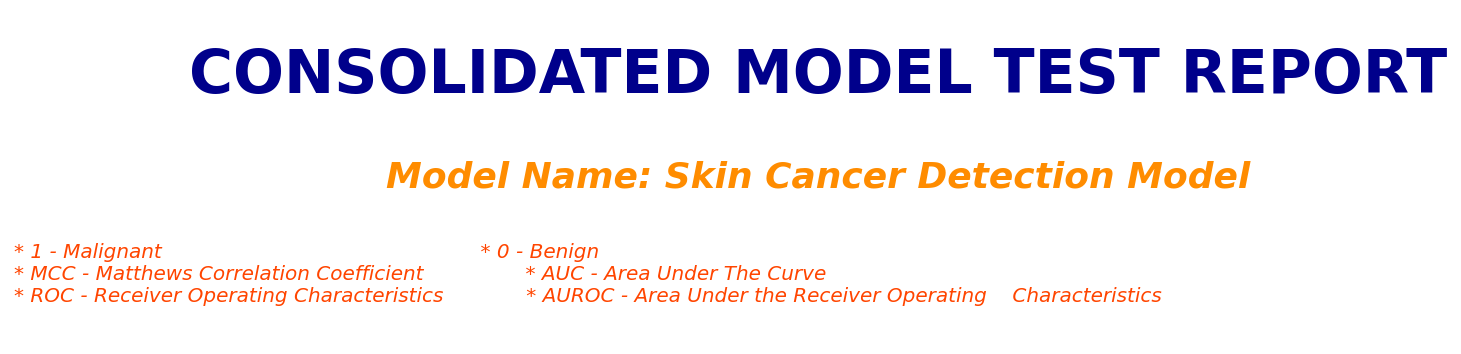

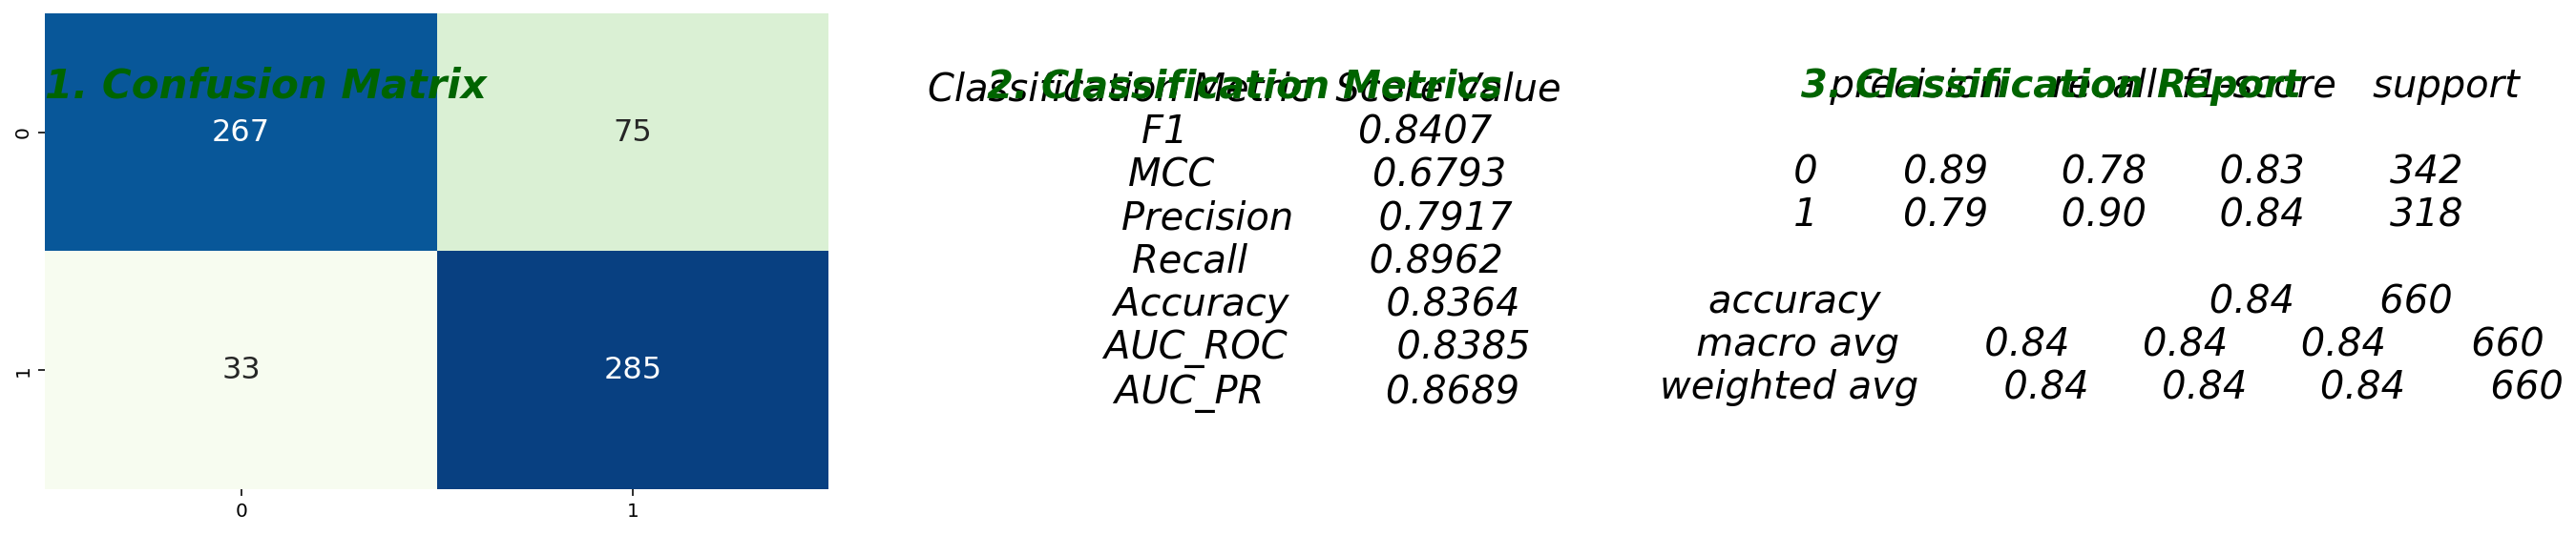

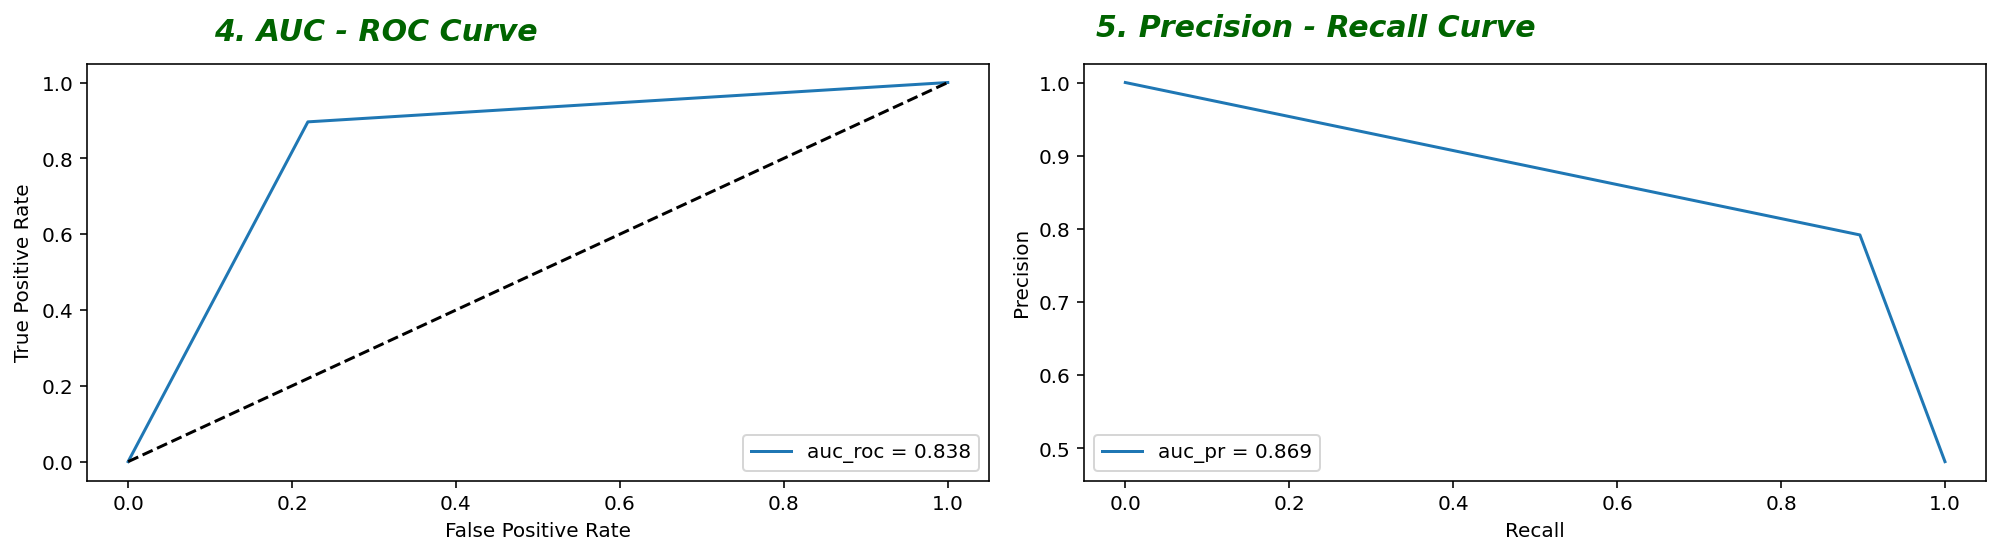

In [36]:
ValidateSkinCancerClassfier.Generate_Model_Test_Classification_Report(y_test, 
                                                                      y_preds_binary, 
                                                                      "Skin Cancer Detection Model")

<br>

***Model test results of 16 random test images...***

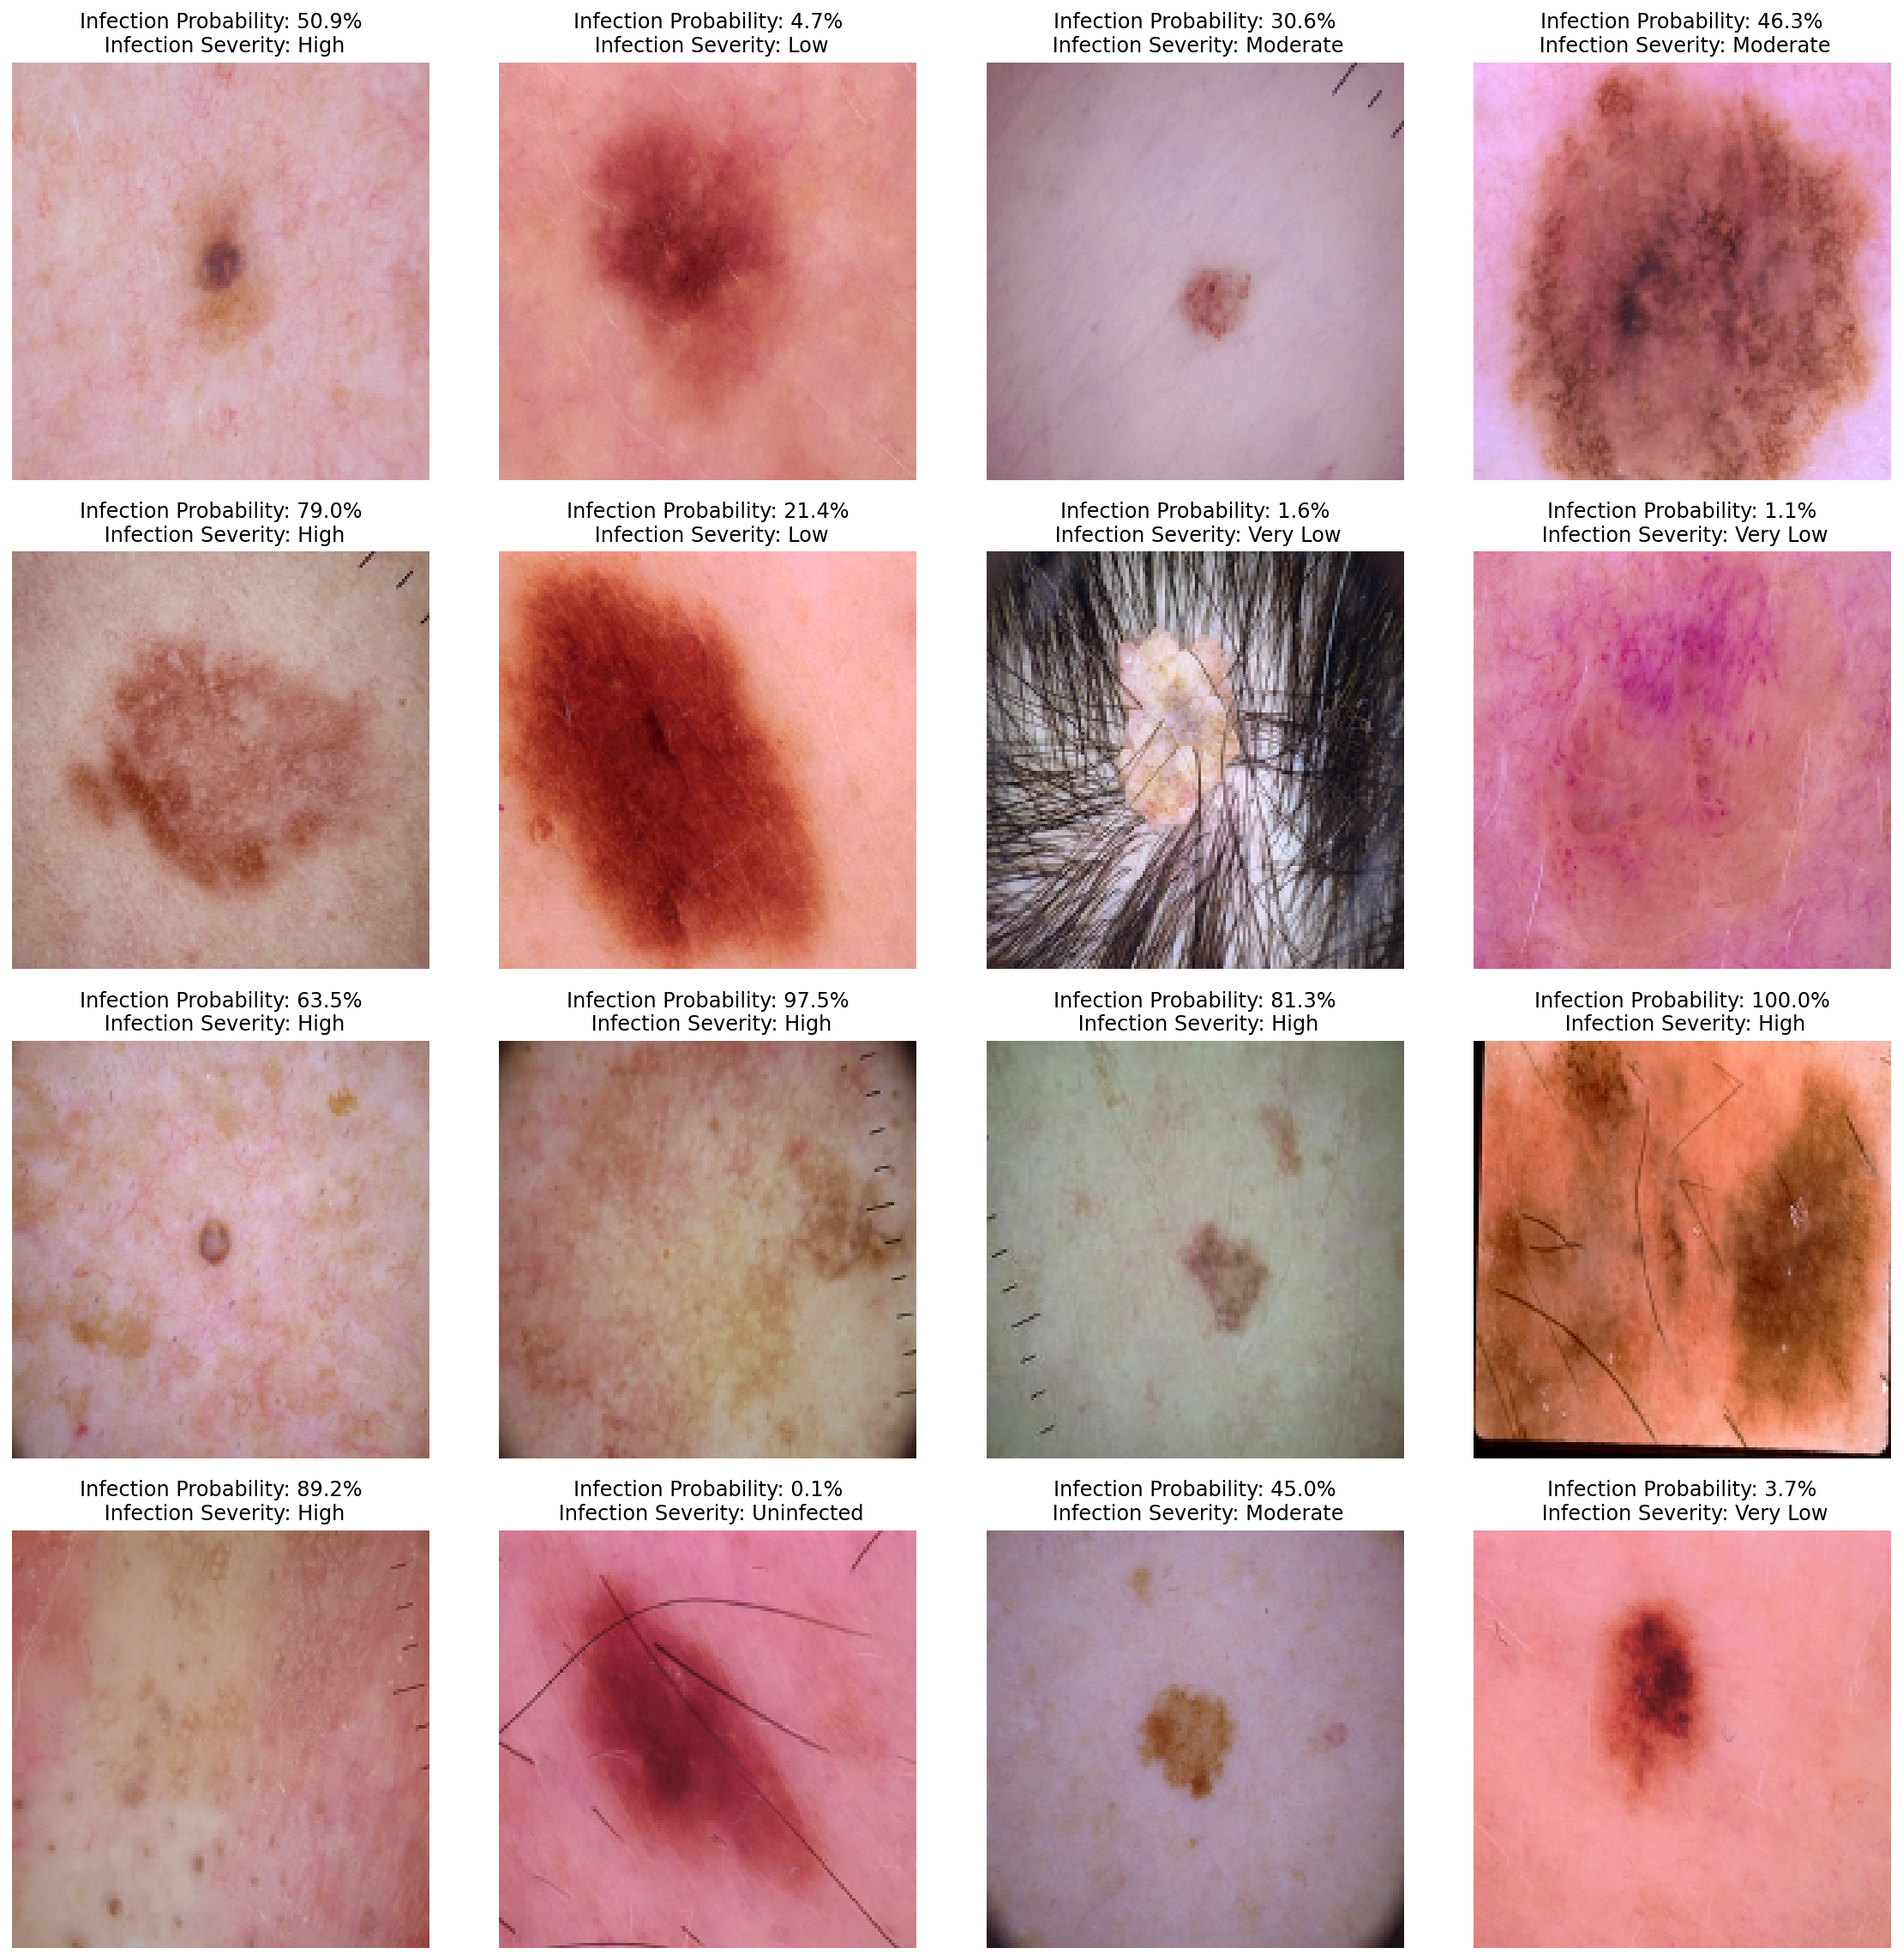

In [37]:
ValidateSkinCancerClassfier.PlotModelPredictionsOnRandomTestImages(X_test, y_test, y_preds_probability)

# Explainable AI: GradCAM and GradCAM++

### Method 1

In [38]:
from GradCamUtility import GradCamUtils
gCam = GradCamUtils(functional_model, "block5_conv4")

1/1 [==============================] - 0s 129ms/step
Probability of the tumor being malignant is: 0.986633


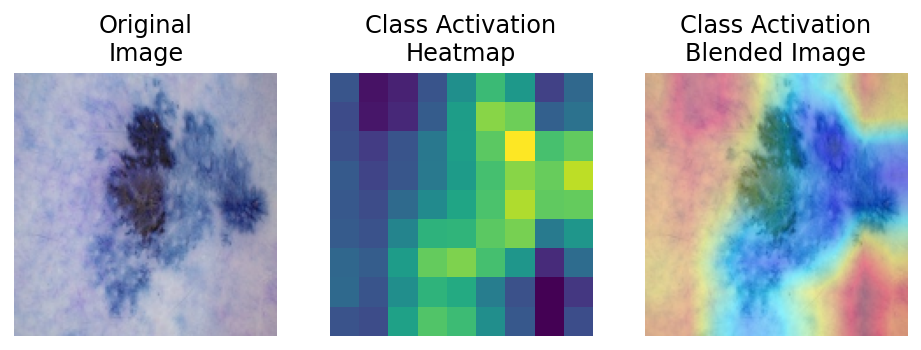

In [39]:
img = cv2.cvtColor(X_test[100], cv2.COLOR_BGR2RGB)
imgAsTensor = np.expand_dims(img, axis=0)

# get the probability of this tumor being malignant
probability = functional_model.predict(imgAsTensor)
print("Probability of the tumor being malignant is:", probability[0][0])

# generate the heatmap
heatmap = gCam.compute_heatmap(imgAsTensor)

# generate the superimposed images and display
superImposedImg = gCam.GetSuperImposedCAMImage(heatmap = heatmap, image = img)
gCam.DisplaySuperImposedImages(image = img, heatmap = heatmap, superimposed_img = superImposedImg)

1/1 [==============================] - 0s 129ms/step
Probability of the tumor being malignant is: 0.25002632


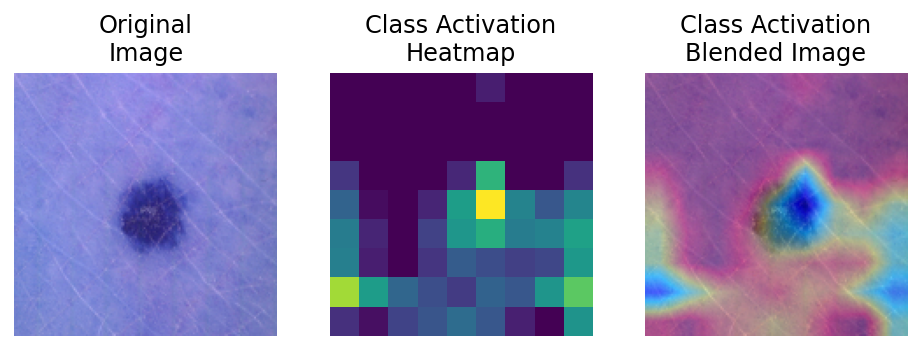

In [40]:
img = cv2.cvtColor(X_test[45], cv2.COLOR_BGR2RGB)
imgAsTensor = np.expand_dims(img, axis=0)

# get the probability of this tumor being malignant
probability = functional_model.predict(imgAsTensor)
print("Probability of the tumor being malignant is:", probability[0][0])

# generate the heatmap
heatmap = gCam.compute_heatmap(imgAsTensor)

# generate the superimposed images and display
superImposedImg = gCam.GetSuperImposedCAMImage(heatmap = heatmap, image = img)
gCam.DisplaySuperImposedImages(image = img, heatmap = heatmap, superimposed_img = superImposedImg)